<a href="https://colab.research.google.com/github/tomarjyoti16/ml-assesment-JyotiTomar-bitsom_ba_2511563/blob/main/part_a/q2_unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q2 Unsupervised Learning
Task 1 : Data Preparation (K-Means)

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#Load data from file
df = pd.read_csv('sample_data/q2_customers.csv')

#preview data
print("Shape:", df.shape)
print("\nFirst 5 rows\n",df.head())

#Scaling features

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

#Converting scaled data to datset
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

print("\nScaled Data Preview:\n", scaled_df.head())






Shape: (500, 6)

First 5 rows
    age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Scaled Data Preview:
         age  annual_spend  visits_per_month  basket_size  \
0 -0.725219     -0.176150          0.110166    -0.265011   
1 -1.488460     -1.046826          0.486157    -0.980466   
2  0.176795      0.267337         -0.453822    -0.236851   
3 -0.725219     -1.012309          0.298161    -0.827783 

Key Reasons for Scaling Before K-Means:
* Prevents Dominance of High-Magnitude Features: Without scaling, features with large numeric ranges exert more influence on cluster formation, essentially forcing the algorithm to ignore features with smaller ranges.

* Equal Feature Contribution: Scaling ensures all features contribute equally to the calculation of distances, allowing for more balanced and representative clustering.

* Improves Accuracy: When features have different units, scaling ensures the distance calculation focuses on the relationships between data points rather than the magnitude of their units.
Faster Convergence: Normalized data helps the K-Means algorithm reach convergence faster, enhancing overall computational efficiency.


2. Choosing K — Elbow Method

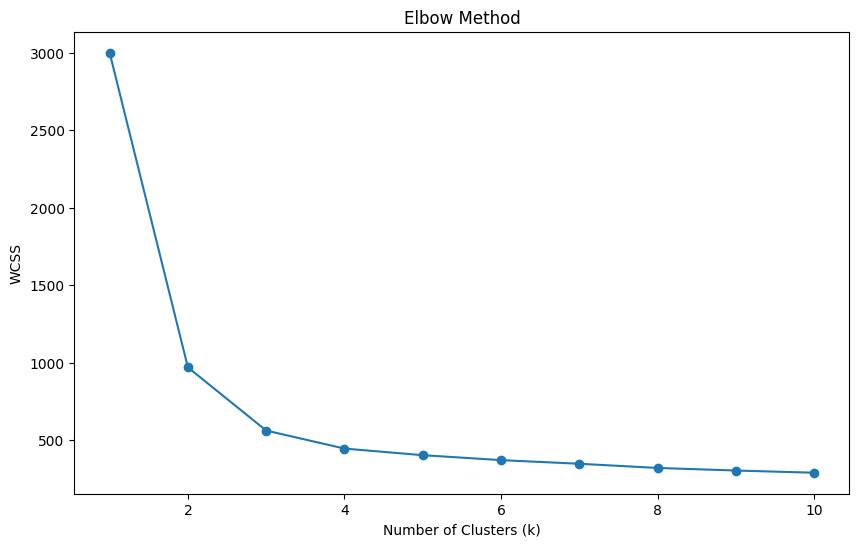

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#Load dataset from file
df = pd.read_csv('sample_data/q2_customers.csv')

#Scaling features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

#Computing WCSS for k = 1 to 100

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)
    #print(f"WCSS for k={k}: {wcss[-1]}")

#Plot Elbow graph
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

#Converting scaled data to dataset

From the plot it is observed that:

* There is a sharp drop from K = 1 to K = 3
* After K = 3 or 4, the decrease becomes gradual
* K = 3 captures most of the variance in the data
Increasing K beyond this point gives diminishing returns
* Choosing K = 3 keeps the model simple, interpretable, and efficient

Thus, the optimal number of clusters is K = 3 (or K = 4)

Task 3: K-Means Clustering

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#Load dataset from file
df = pd.read_csv('sample_data/q2_customers.csv')

#Scaling features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

#Applying K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

#Adding cluster labels to original dataset
df['Cluster'] = clusters

print("Data with Cluster Lables:\n", df.head())

#Cluster centriods
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=df.columns[:-1])
print("\nCluster Centroids:\n", centroid_df)





Data with Cluster Lables:
    age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  Cluster  
0                         6        2  
1                         3        0  
2                         4        2  
3                         2        0  
4                         1        0  

Cluster Centroids:
          age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   d

Cluster Interpretation:

* Cluster 0:
Represents young customers with moderate spending and frequent visits. These customers are engaged and visit regularly but do not spend very high amounts.

* Cluster 1:
Represents high-value customers with high annual spending and larger basket sizes. These are premium customers who contribute significantly to revenue and should be targeted with loyalty programs.

* Cluster 2:
Represents low-spending customers with fewer visits and smaller basket sizes. These customers are less engaged and may require marketing efforts to increase activity.


Task 4: Dimensionality Reduction with PCA

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#Load dataset from file
df = pd.read_csv('sample_data/q2_customers.csv')

#Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

#Apply PCA (2 components)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

#Explained Variance Ratio
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance_ratio)

#Feature Loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns,
    index=['PC1', 'PC2']
)
print("\nFeature Loadings:\n", loadings
)

Explained Variance Ratio: [0.83560354 0.05568764]

Feature Loadings:
           age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


PC1 has high positive loadings for:
annual_spend
basket_size
visits_per_month
num_categories_purchased

Interpretation:
PC1 represents overall customer value / spending behavior.

High PC1 score → customers who spend more, buy more items, visit frequently and purchase across categories
Low PC1 score → low-value / less engaged customers

PC2 (Principal Component 2):
PC2 typically shows:
Positive loading for days_since_last_visit
Mixed or negative loadings for visit/spend features

Interpretation:
PC2 represents customer recency vs engagement.

High PC2 score → customers who haven’t visited recently and possibly becoming inactive
Low PC2 score → customers who Visit frequently and are actively engaged

Task 5: Cluster Visualisation (PCA)

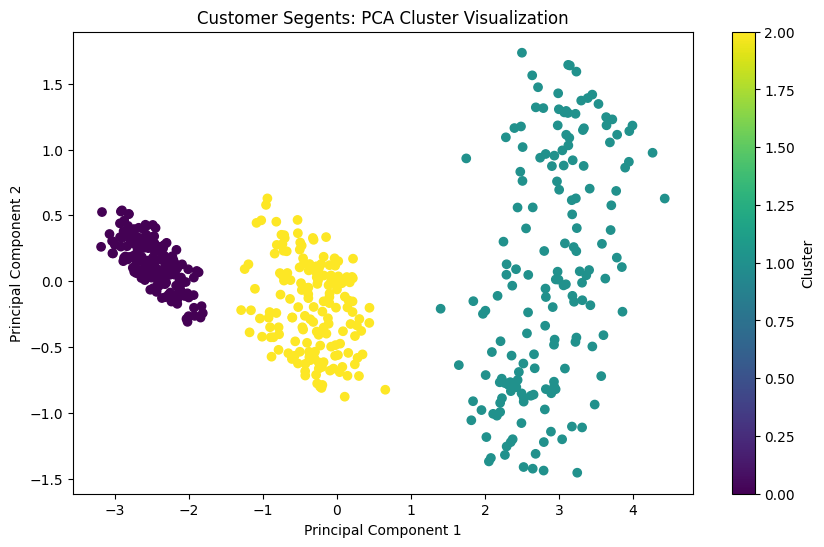

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#Load dataset from file
df = pd.read_csv('sample_data/q2_customers.csv')

#Scaled data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

#Apply PCA (2 components)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

#Apply K-Mean (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

#Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=clusters,
    cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segents: PCA Cluster Visualization')
plt.colorbar(label='Cluster')
plt.show()

The scatter plot shows that customers are grouped into distinct clusters, indicating clear differences in their behavior patterns.
Some overlap between clusters suggests that while segments are generally well-separated, a few customers share similar characteristics across groups.